In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [6]:
df=pd.read_csv('Mall_Customers.csv')

In [7]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
df=df.drop('CustomerID',axis=1)

In [10]:
df['Genre'].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

In [11]:
df['Genre']=df['Genre'].map({'Female' : 0 ,'Male' :1})

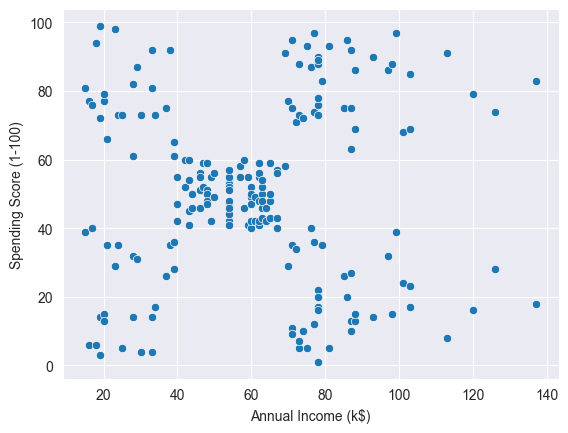

In [14]:
sns.scatterplot(data=df,x='Annual Income (k$)' ,y='Spending Score (1-100)')
plt.show()

In [17]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [18]:
wcss = []

In [20]:

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

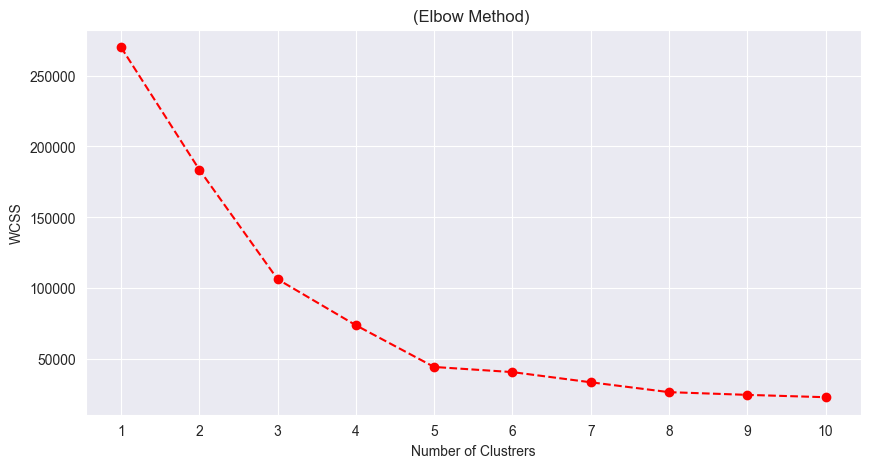

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='red')
plt.xticks(range(1,11))
plt.title('(Elbow Method) ')
plt.xlabel('Number of Clustrers')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [24]:
#As we can see in the graph, it is divided into 5 clusters.

In [25]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

In [26]:
y_kmeans = kmeans.fit_predict(X)

In [27]:
df['Customer_type'] = y_kmeans

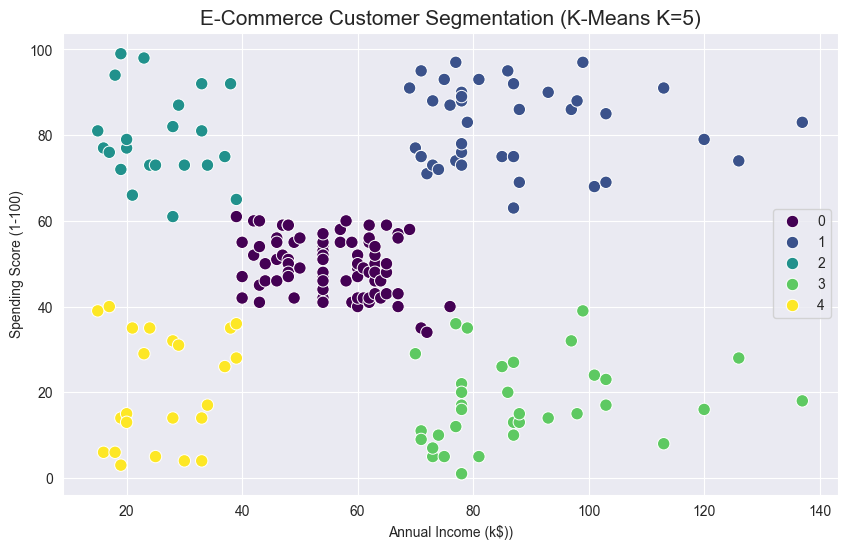

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y_kmeans, palette='viridis', s=80)
plt.title('E-Commerce Customer Segmentation (K-Means K=5)', fontsize=15)
plt.xlabel('Annual Income (k$))')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

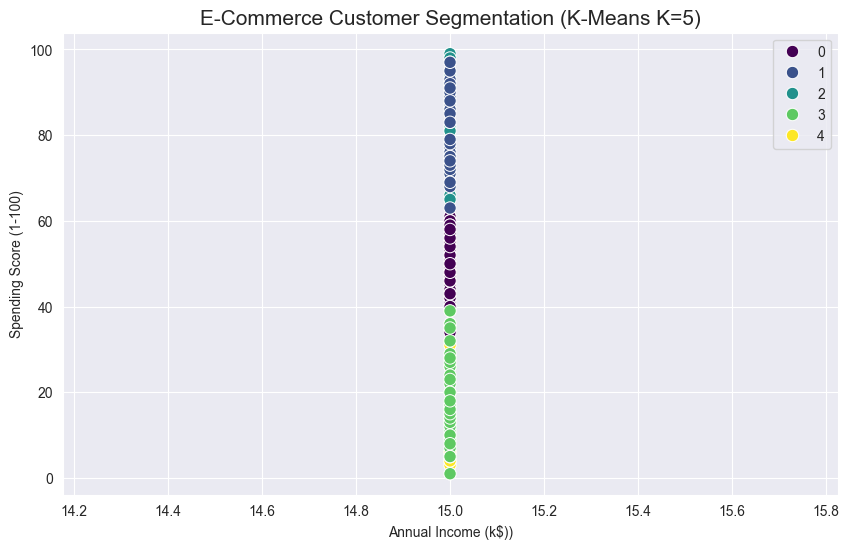

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y_kmeans, palette='viridis', s=80)
plt.title('E-Commerce Customer Segmentation (K-Means K=5)', fontsize=15)
plt.xlabel('Annual Income (k$))')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()